# Processing Categorical Data

It is often useful to measure objects not in terms of their quantity but in terms of some quality. In data analysis, these qualities are often represented as **categorical features**, which describe characteristics using distinct groups or categories rather than numerical values. Categorical data can generally be divided into **nominal categories**, which have no inherent order (such as red, blue, green), and **ordinal categories**, where the categories follow a meaningful ranking or order (such as low, medium, high). Although categorical features are common in real-world datasets, typical applications require them to be represented in a numerical form.

In this episode, we will focus on several important techniques for processing categorical data. We will explore how to encode nominal and ordinal categorical features, work with dictionaries of features, and impute missing class. Understanding these techniques is essential for preparing categorical data effectively and ensuring that it can be used reliably in machine learning models.

<div class='alert alert-info'>

:::{objectives}
- Understand the difference between nominal and ordinal categorical features.
- Learn how to encode categorical features for machine learning.
- Understand how to work with dictionaries of features.
- Learn techniques for handling missing categorical values.
:::
</div>

<div class='alert alert-success'>

:::{instructor-note}
- 30 minutes teaching
- 15 minutes exercising/discussion
:::
</div>

## 1. Getting Started with Categorical Data

**Categorical data** refers to data that represents the qualities, characteristics, or groups of an observation rather than a numerical quantity. Instead of measuring something with a number, categorical variables describe which category an observation belongs to. For example, a person's gender, a product type, or a customer’s satisfaction level can all be represented as categorical data.

Categorical features are commonly divided into two main types: nominal and ordinal.
- **Nominal categories** have no natural order, such as colors or product types.
- **Ordinal categories** have a meaningful order, such as low, medium, and high.

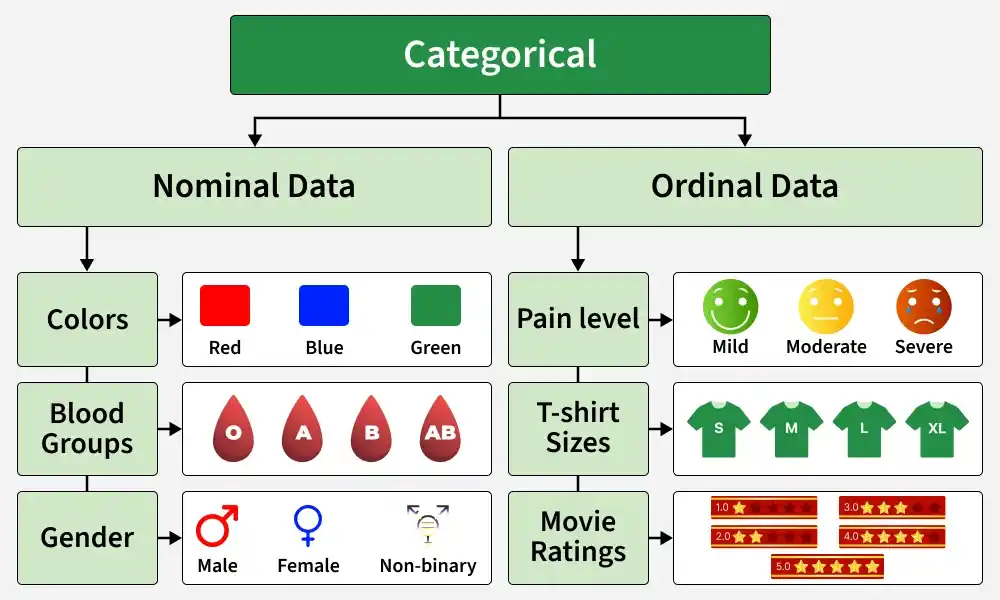

In [1]:
from IPython.display import display, Image
display(Image(filename='../images/categorical-data/categorical-data.png', width=1024))

When working with categorical data in data analysis and machine learning, these features often need to be transformed into a format that algorithms can understand.
Typically, **categorical data should be represented using numerical values rather than raw strings**, allowing relevant algorithms to process and analyze these features effectively.
This may involve using different encoding techniques for nominal and ordinal features, representing categorical information using dictionaries of features, and dealing with practical issues such as missing class values.

## 2. Encoding Nominal Categorical Features

Below are some representative examples of nominal categorical features.
- color: Red, Blue, Green
- city: Stockholm, Uppsala, Lund, Linkoping

A key characteristic of nominal features is that they have **no inherent order or ranking**, and there is **no meaningful numerical relationship between their categories**.
In other words, we cannot say that one category is better, more important, or higher than another; the categories simply represent different groups or labels.

### 2.1 One-hot encoding (OHE)

How can we represent this information numerically without introducing a false ordering between the categories? This naturally leads us to **one-hot encoding** (OHE).
- OHE is a technique that converts each category into a separate binary feature, typically represented as 0 or 1.
- OHE is well supported in scikit-learn, and below are some code snippets demonstrating how to encode nominal categorical features.

In [2]:
import pandas as pd

city_df = pd.DataFrame({"city": ["Stockholm", "Linkoping", "Lund", "Stockholm", "Uppsala", "Linkoping"]})
city_df

,city
0,Stockholm
1,Linkoping
2,Lund
3,Stockholm
4,Uppsala
5,Linkoping


OHE is implemented in scikit-learn using the `OneHotEncoder` class.

In [3]:
from sklearn.preprocessing import OneHotEncoder

ohe_encoder = OneHotEncoder(sparse_output=False)

ohe_encoder.fit(city_df[["city"]])
city_names = ohe_encoder.categories_[0]
print(city_names, '\n')

city_ohe = ohe_encoder.fit_transform(city_df[["city"]])
city_ohe = pd.DataFrame(city_ohe, columns=city_names).astype(int)

city_df_ohe = pd.concat([city_df, city_ohe], axis=1)
city_df_ohe

['Linkoping' 'Lund' 'Stockholm' 'Uppsala'] 



,city,Linkoping,Lund,Stockholm,Uppsala
0,Stockholm,0,0,1,0
1,Linkoping,1,0,0,0
2,Lund,0,1,0,0
3,Stockholm,0,0,1,0
4,Uppsala,0,0,0,1
5,Linkoping,1,0,0,0


In the preceding code snippets, `fit_transform()` is a two-step operation.
- First, `fit` means that the transformer learns necessary information from data. In this case, it means identifying the list of unique categories in the data.
- Then, `transform` means that the transformer uses what it has learned to convert the data into the desired representation. Here, it converts each category into its corresponding OHE representation.
- Therefore, `fit_transform()` performs both steps at once: it first learns from the data and then transforms that same data using the information it has learned.

<div class='alert alert-warning'>

:::{warning}
After OHE encoding, we typically obtain a sparse matrix, where most of the entries are 0s. For a small dataset with a limited number of features, such a matrix is relatively easy to handle. However, for **high-cardinality features**, which are categorical features containing a large number of unique categories, using OHE can become problematic because each unique category creates a new column.

For example, if a dataset contains 100,000 unique product IDs, OHE could create 100,000 additional columns, resulting in a very large and mostly sparse matrix. To address this issue, sparse matrix representations store only the non-zero values and their corresponding positions rather than explicitly storing all the zeros. This can significantly reduce memory usage and improve computational efficiency when working with high-dimensional categorical data.
:::
</div>

### 2.2 Label encoding 

If we want to avoid creating a large sparse matrix, we can use **label encoding** to transform categorical data. Label encoding transforms a categorical feature into a single numerical column by assigning a unique integer to each category. This produces a much more compact representation and can be more memory-efficient, especially when feature contains a large number of unique categories.

In [20]:
from sklearn.preprocessing import LabelEncoder
lb_encoder = LabelEncoder()

city_lb = lb_encoder.fit_transform(city_df["city"])
city_lb = pd.DataFrame(city_lb, columns=["LB_encoded"])

city_df_ohe_lb = pd.concat([city_df_ohe, city_lb], axis=1)
city_df_ohe_lb

,city,Linkoping,Lund,Stockholm,Uppsala,LB_encoded
0,Stockholm,0,0,1,0,2
1,Linkoping,1,0,0,0,0
2,Lund,0,1,0,0,1
3,Stockholm,0,0,1,0,2
4,Uppsala,0,0,0,1,3
5,Linkoping,1,0,0,0,0


However, label encoding introduces an **artificial ordinal relationship** between categories.
For example, assigning a larger value to Uppsala than Linköping may incorrectly imply that Uppsala is somehow greater or more important than Linköping.
This relationship may not be meaningful and can negatively affect algorithms that assume numerical values have an inherent order. Therefore, we need to take this limitation into consideration when choosing and interpreting the encoding method.

## 3. Encoding Ordinal Categorical Features

However, if categorical features have a natural and meaningful ordering, such as student performance levels classified as Low, Medium, and High, ordinal encoding can be a good choice. It is important to assign numerical values based on prior knowledge of the ordinal categories and their relationships. For example, assigning Low = 1, Medium = 2, and High = 3 implicitly suggests that the intervals between the categories are equal.

In [21]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

score_df = pd.DataFrame({"Score": ["Low", "Low", "Medium", "Medium", "High"]})

encoder = OrdinalEncoder(categories=[["Low", "Medium", "High"]])

score_df["Score_Encoded"] = encoder.fit_transform(score_df[["Score"]]).astype(int) + 1
print(score_df)

    Score  Score_Encoded
0     Low              1
1     Low              1
2  Medium              2
3  Medium              2
4    High              3


While this assumption may be reasonable in many cases, **it can be misleading when the distances between ordinal categories are not equal**.
For example, suppose we have a category called "Barely More Than Medium", which is only slightly higher than Medium. In this case, we need to carefully consider the numerical values assigned to each category. The interval between Low and Medium may be substantially larger than the interval between Medium and Barely More Than Medium.

In [22]:
score_df = pd.DataFrame({
    "Score": ["Low", "Low", "Medium", "Medium", "High", "Barely More Than Medium"]
})

encoder = OrdinalEncoder(
    categories=[["Low", "Medium", "Barely More Than Medium", "High"]]
)

score_df["Score_Encoded"] = encoder.fit_transform(score_df[["Score"]]).astype(int) + 1
print(score_df)

                     Score  Score_Encoded
0                      Low              1
1                      Low              1
2                   Medium              2
3                   Medium              2
4                     High              4
5  Barely More Than Medium              3


In such cases, it may be more appropriate to use a **custom dictionary mapping** rather than `OrdinalEncoder`.
A dictionary allows us to explicitly assign numerical values that better reflect the actual relationships between the ordinal categories, based on domain knowledge.

In [7]:
score_mapping = {
    "Low": 1,
    "Medium": 2,
    "Barely More Than Medium": 2.2,
    "High": 3
}

score_df["Score_Encoded"] = score_df["Score"].map(score_mapping)
print(score_df)

                     Score  Score_Encoded
0                      Low            1.0
1                      Low            1.0
2                   Medium            2.0
3                   Medium            2.0
4                     High            3.0
5  Barely More Than Medium            2.2


## 4. Encoding Dictionaries of Features

A dictionary is a widely used data structure for storing data as key–value pairs. This representation is particularly common in natural language processing (NLP). For example, we might have a collection of documents, where each document is represented by a dictionary containing each word as a key and the number of times that word appears in the document as its value.

In [8]:
# create word count dictionaries for four documents
doc_1_word_count = {"Red": 2, "Green": 4}
doc_2_word_count = {"Green": 4, "Blue": 3}
doc_3_word_count = {"Yellow": 2, "Red": 1}
doc_4_word_count = {"Orange": 5, "Yellow": 3}

doc_word_counts = [doc_1_word_count, doc_2_word_count, doc_3_word_count, doc_4_word_count]
doc_word_counts

[{'Red': 2, 'Green': 4},
 {'Green': 4, 'Blue': 3},
 {'Yellow': 2, 'Red': 1},
 {'Orange': 5, 'Yellow': 3}]

However, when performing data analysis or applying machine learning algorithms, we typically expect the data to be represented as a feature matrix.

Using **DictVectorizer** from scikit-learn, we can easily transform a collection of dictionaries into a feature matrix, where each unique word becomes a feature and each matrix entry represents the number of times that word appears in a particular document.

In [9]:
from sklearn.feature_extraction import DictVectorizer

# create dictionary vectorizer
dictvectorizer = DictVectorizer(sparse=False)

# convert list of word count dictionaries into feature matrix
features = dictvectorizer.fit_transform(doc_word_counts)
features

array([[0., 4., 0., 2., 0.],
       [3., 4., 0., 0., 0.],
       [0., 0., 0., 1., 2.],
       [0., 0., 5., 0., 3.]])

In [10]:
# get feature names
feature_names = dictvectorizer.get_feature_names_out()
feature_names

array(['Blue', 'Green', 'Orange', 'Red', 'Yellow'], dtype=object)

In [11]:
doc_word_counts_dictvec = pd.DataFrame(features, 
    index=[
        "doc_1_word_count",
        "doc_2_word_count",
        "doc_3_word_count",
        "doc_4_word_count"
    ],
    columns=feature_names).astype(int)
doc_word_counts_dictvec

,Blue,Green,Orange,Red,Yellow
doc_1_word_count,0,4,0,2,0
doc_2_word_count,3,4,0,0,0
doc_3_word_count,0,0,0,1,2
doc_4_word_count,0,0,5,0,3


In this toy example, there are only five unique words (Red, Yellow, Blue, Orange, and Green), so the feature matrix contains only five features. However, imagine that each document is an entire book from a university library. In that case, the number of unique words, and therefore the number of features, could become extremely large. The resulting matrix would also be very sparse, with most entries equal to zero.

To handle such a high-dimensional dataset efficiently, we can configure `DictVectorizer` to return a sparse matrix by setting `sparse=True`. This allows the vectorizer to store only the non-zero values, significantly reducing memory usage.

## 5. Imputing Missing Class Values

When handling a dataset with missing values in a categorical feature, one effective approach is to use a machine learning algorithm to predict the missing values. We can accomplish this by treating the categorical feature with missing values as the target vector, while using the other available features as the feature matrix.

Here, we have a smaller version of the Penguins dataset. It contains 30 penguins, with two numerical features, body mass and flipper length, and one categorical feature, species.

In [ ]:
import pandas as pd

# 30 penguin samples
penguins = pd.DataFrame({
    "Species": [
        "Adelie", "Adelie", None, "Adelie", "Adelie",
        "Adelie", "Adelie", "Adelie", "Adelie", "Adelie",
        "Chinstrap", "Chinstrap", "Chinstrap", None, "Chinstrap",
        "Chinstrap", "Chinstrap", "Chinstrap", "Chinstrap", "Chinstrap",
        "Gentoo", "Gentoo", "Gentoo", "Gentoo", "Gentoo",
        None, "Gentoo", "Gentoo", "Gentoo", "Gentoo"
    ],
    "Body_Mass (g)": [
        3700, 3700, 3800, 3900, 4000,
        4100, 3500, 3750, 3750, 3950,
        3500, 3650, 3800, 3850, 4150,
        4050, 3950, 3700, 3900, 4000,
        5000, 5100, 5200, 5300, 4950,
        5150, 5250, 5400, 5050, 5350
    ],
    "Flipper_Length (mm)": [
        180, 182, 184, 186, 188,
        190, 179, 185, 187, 189,
        181, 183, 187, 187, 189,
        191, 184, 186, 188, 190,
        215, 220, 225, 230, 218,
        222, 227, 232, 217, 229
    ]
})
print(penguins)

      Species  Body_Mass (g)  Flipper_Length (mm)
0      Adelie           3700                  180
1      Adelie           3700                  182
2         NaN           3800                  184
3      Adelie           3900                  186
4      Adelie           4000                  188
5      Adelie           4100                  190
6      Adelie           3500                  179
7      Adelie           3750                  185
8      Adelie           3750                  187
9      Adelie           3950                  189
10  Chinstrap           3500                  181
11  Chinstrap           3650                  183
12  Chinstrap           3800                  187
13        NaN           3850                  187
14  Chinstrap           4150                  189
15  Chinstrap           4050                  191
16  Chinstrap           3950                  184
17  Chinstrap           3700                  186
18  Chinstrap           3900                  188


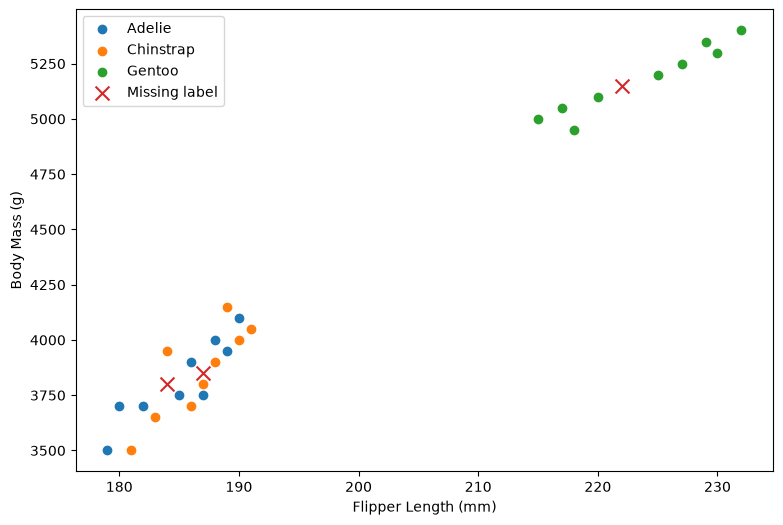

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for species in ["Adelie", "Chinstrap", "Gentoo"]:
    data = penguins[penguins["Species"] == species]
    plt.scatter(
        data["Flipper_Length (mm)"],
        data["Body_Mass (g)"],
        label=species
    )

# plot samples with missing labels
missing = penguins[penguins["Species"].isna()]
plt.scatter(
    missing["Flipper_Length (mm)"],
    missing["Body_Mass (g)"],
    marker="x",
    s=100,
    label="Missing label"
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend()
plt.tight_layout
plt.show()

In this example, we use an algorithm called **k-Nearest Neighbors** (**kNN**) to predict the missing class labels. KNN identifies the `k` observations that are closest to the observation with the missing value and **assigns it the most frequent class among those nearest neighbors**. In this way, the missing categorical values can be inferred from the patterns in the other features.

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# features used for classification
features = ["Body_Mass (g)", "Flipper_Length (mm)"]

# separate known and missing observations
known = penguins["Species"].notna()
missing = penguins["Species"].isna()

# training data
X_train = penguins.loc[known, features]
y_train = penguins.loc[known, "Species"]

# data with missing species labels
X_missing = penguins.loc[missing, features]

# standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_missing_scaled = scaler.transform(X_missing)

# create and train kNN model
knn = KNeighborsClassifier(n_neighbors=3) # try different odd numbers
knn.fit(X_train_scaled, y_train)

# predict missing species
predictions = knn.predict(X_missing_scaled)

# display predictions
print("Predicted species:")
for index, prediction in zip(penguins.index[missing], predictions):
    print(f"Row {index}: {prediction}")

Predicted species:
Row 2: Adelie
Row 13: Chinstrap
Row 25: Gentoo


We have other options for handling missing categorical values. For example, we could **discard the observations with missing values**, or we could **use more sophisticated algorithms to predict and imputate those missing values**.
- The first approach can be rather crude, especially when a large number of observations have missing values. There may be many reasons why values are missing, and simply discarding these observations could result in the loss of valuable information.
- The second approach, using machine learning or other advanced imputation techniques, can preserve more of the available data and is often more scalable to larger datasets.

## 6. Encoding Strategies

Beyond these common methods, there are several other encoding strategies that can be especially useful when working with more complex datasets:
- **Binary Encoding**: Converts categories into binary representations, providing a useful compromise between OHE and label encoding, particularly for high-cardinality categorical features.
- **Target Encoding** (Mean Encoding): Replaces each category with the average value of the target variable for that category. This can be powerful, but it must be carefully implemented to avoid overfitting and data leakage.
- **Frequency Encoding**: Replaces each category with its frequency or proportion of occurrence in the dataset. This can be useful for reducing the dimensionality of high-cardinality features.

Below, we provide a comprehensive summary of these methods, including their pros and cons and representative applications.

| Method                     | Pros                                                      | Cons                                                     | Representative Applications                        |
| :------------------------: | :-------------------------------------------------------: | :------------------------------------------------------: | :------------------------------------------------: |
| **One-Hot Encoding (OHE)** | Simple; no artificial order; interpretable                | Many columns; memory-intensive for high cardinality      | Country, color, product type, gender               |
| **Label Encoding**         | Simple; compact; memory-efficient                         | Artificial ordering for nominal data                     | Tree-based models; binary categories               |
| **Ordinal Encoding**       | Preserves natural order; easy to implement                | Assumes numeric spacing is meaningful                    | Education level, satisfaction, size                |
| **Dictionary Mapping**     | Flexible; custom numeric values                           | Requires domain knowledge; manual                        | Custom ordinal scales, expert-defined scores       |
| **DictVectorizer**         | Converts dictionaries to matrices; supports sparse output | High dimensionality with many features                   | NLP, word counts, dictionary-based data            |
| **KNN / ML Imputation**    | Uses other features; preserves observations               | Computationally expensive; prediction errors             | Missing class/category values                      |
| **Binary Encoding**        | Fewer columns; good for high cardinality                  | Less interpretable; more complex                         | Product IDs, ZIP codes, large categorical datasets |
| **Target Encoding**        | Compact; effective for high cardinality                   | Overfitting/data leakage risk                            | Product category, merchant ID, customer segment    |
| **Frequency Encoding**     | Simple; compact; handles high cardinality                 | Loses category identity; frequency may not be predictive | Product IDs, website IDs, transaction categories   |

Overall, **there is no single best encoding method for every dataset**. The choice of encoding is an important modeling decision and should be guided by several factors, including whether the categorical variable is nominal or ordinal, the number of unique categories (cardinality), the amount of available data, and the type of algorithm being used. A well-chosen encoding method represents categorical information in a way that allows the model to learn meaningful patterns while minimizing the risk of introducing artificial relationships, bias, noise, or unnecessary computational complexity.

<div class='alert alert-success'>

:::{exercise}
After completing the individual tasks for handling categorical data, it is now time to bring everything together in a hands-on exercise. We will contine to work on representative datasets as listed below.

- **Select a dataset**: Choose one dataset from scikit-learn: Iris, Diabetes, Wine, Breast Cancer, or California Housing.
    ```python
    from sklearn import datasets

    iris = datasets.load_iris(as_frame=True)
    iris_df = iris.frame
    iris_df.head()

    diabetes = datasets.load_diabetes(as_frame=True)
    diabetes_df = diabetes.frame
    diabetes_df.head()

    wine = datasets.load_wine(as_frame=True)
    wine_df = wine.frame
    wine_df.head()

    cancer = datasets.load_breast_cancer(as_frame=True)
    cancer_df = cancer.frame
    cancer_df.head()

    housing = datasets.fetch_california_housing(as_frame=True)
    housing_df = housing.frame
    housing_df.head()
    ```
- **Explore categorical features**: Examine the unique categories and their frequencies to understand how the categorical variables are distributed.
- **Identify nominal and ordinal categorical features in dataset**.
- **Encode categorical features**: Convert categorical variables into numerical representations using appropriate techniques, such as ordinal encoding, one-hot encoding, or feature hashing.
- **Check for missing values**: Identify missing values in categorical features and calculate their counts and percentages.
- **Decide how to handle missing categorical values**: Determine whether to remove observations or impute the missing values using an appropriate method, such as the most frequent category or a machine learning approach.
:::
</div>

<div class='alert alert-info'>

:::{keypoints}
- Distinguish between nominal and ordinal categorical features and understand when each type of encoding is appropriate.
- Encode categorical data using techniques such as one-hot, label, ordinal, and custom dictionary mapping.
- Transform dictionary-based features into numerical feature matrices using `DictVectorizer`.
- Handle missing categorical values using deletion, statistical approaches, or machine learning-based imputation.
- Select appropriate encoding strategies based on feature type, cardinality, dataset characteristics, and machine learning algorithm.
:::
</div>